```
- Hiểu Pooling là gì
- Max Pooling hoạt động như thế nào
- Average Pooling hoạt động như thế nào
- Vì sao Pooling giúp giảm kích thước dữ liệu
- Pooling ảnh hưởng tới Feature Maps ra sao
- Hiểu gradient của Pooling (chuẩn bị cho Phase B)
```

In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.pooling import (
    MaxPooling2D,
    AveragePooling2D
)

from src.activation import ReLU
from src.convolution import Convolution2D

from src.utils import (
    load_image,
    show_image,
    plot_feature_maps
)

In [3]:
print("=" * 60)
print("CNN FROM SCRATCH")
print("06 - POOLING")
print("=" * 60)

CNN FROM SCRATCH
06 - POOLING


part 1 Max Pooling

In [4]:
feature_map = np.array(
[
    [1,4,2,3],
    [5,6,1,2],
    [2,3,7,8],
    [1,4,5,9]
]
)

print(feature_map)

[[1 4 2 3]
 [5 6 1 2]
 [2 3 7 8]
 [1 4 5 9]]


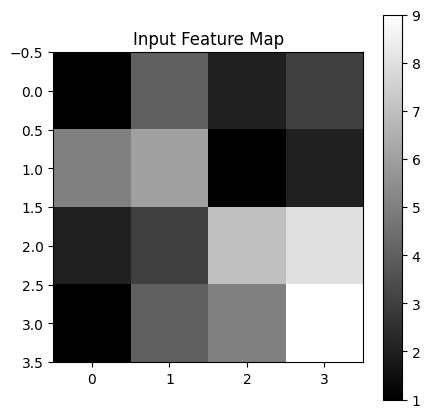

In [5]:
plt.figure(figsize=(5,5))

plt.imshow(
    feature_map,
    cmap="gray"
)

plt.title(
    "Input Feature Map"
)

plt.colorbar()

plt.show()

In [6]:
max_pool = MaxPooling2D(
    pool_size=2,
    stride=2
)

pooled = max_pool.forward(
    feature_map[np.newaxis,:,:]
)

print(pooled[0])

[[6. 3.]
 [4. 9.]]


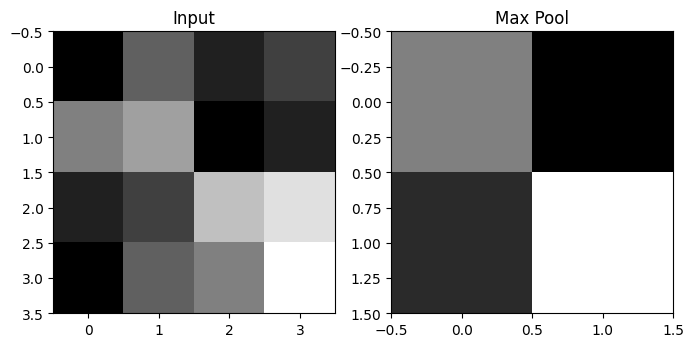

In [7]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(8,4)
)

ax[0].imshow(
    feature_map,
    cmap="gray"
)

ax[0].set_title(
    "Input"
)

ax[1].imshow(
    pooled[0],
    cmap="gray"
)

ax[1].set_title(
    "Max Pool"
)

plt.show()

Part 2 Average Pooling

In [8]:
avg_pool = AveragePooling2D(
    pool_size=2,
    stride=2
)

avg_output = avg_pool.forward(
    feature_map[np.newaxis,:,:]
)

print(avg_output[0])

[[4.   2.  ]
 [2.5  7.25]]


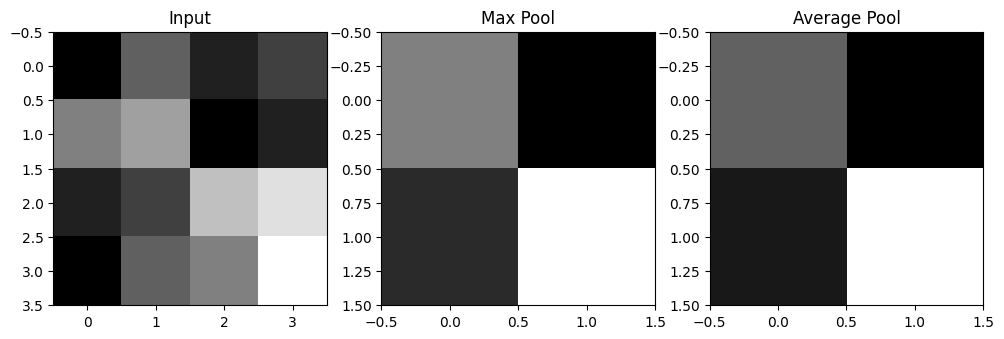

In [9]:
fig, ax = plt.subplots(
    1,
    3,
    figsize=(12,4)
)

ax[0].imshow(
    feature_map,
    cmap="gray"
)

ax[0].set_title(
    "Input"
)

ax[1].imshow(
    pooled[0],
    cmap="gray"
)

ax[1].set_title(
    "Max Pool"
)

ax[2].imshow(
    avg_output[0],
    cmap="gray"
)

ax[2].set_title(
    "Average Pool"
)

plt.show()

Part 3 Pooling Shape Formula

In [10]:
print("""
Pooling Output Shape

Hout =
((H-Pool)//Stride)+1

Wout =
((W-Pool)//Stride)+1
""")


Pooling Output Shape

Hout =
((H-Pool)//Stride)+1

Wout =
((W-Pool)//Stride)+1



In [11]:
H = 8
Pool = 2
Stride = 2

H_out = (
    (H-Pool)//Stride
) + 1

print(
    "Output Height:",
    H_out
)

Output Height: 4


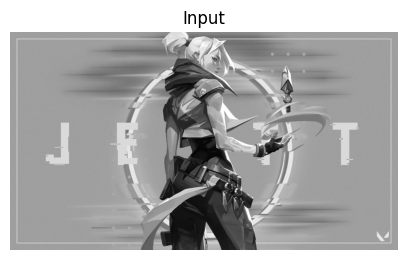

In [12]:
image = load_image(
    "../data/sample.jpg",
    grayscale=True
)

show_image(
    image,
    "Input"
)

In [13]:
conv = Convolution2D(
    in_channels=1,
    out_channels=8,
    kernel_size=3,
    padding=1
)

feature_maps = conv.forward(
    image
)

print(
    feature_maps.shape
)

(8, 1080, 1920)


In [14]:
relu = ReLU()

feature_maps = relu.forward(
    feature_maps
)

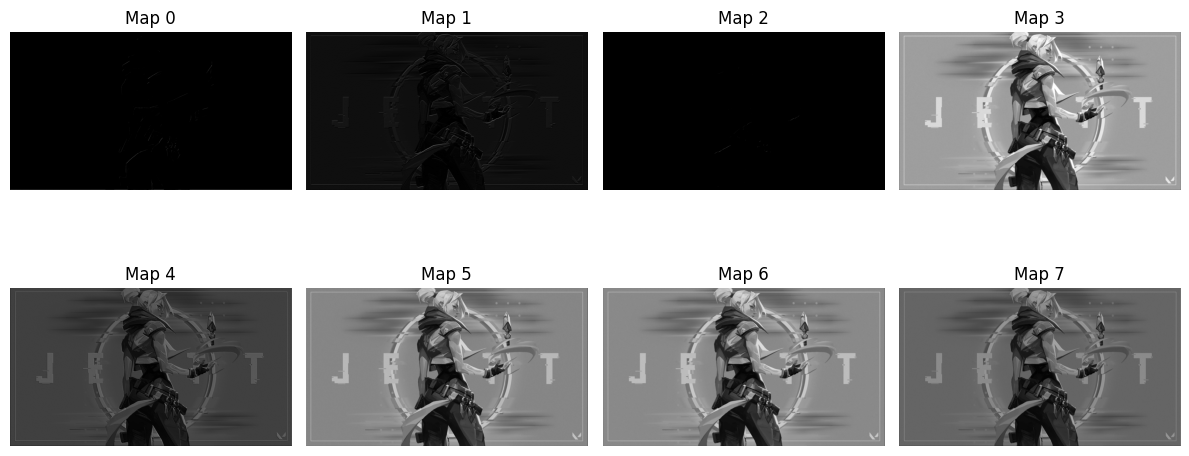

In [15]:
plot_feature_maps(
    feature_maps,
    max_maps=8
)

Part 5 - Apply Max Pooling

In [16]:
pool = MaxPooling2D(
    pool_size=2,
    stride=2
)

pooled_maps = pool.forward(
    feature_maps
)

print(
    pooled_maps.shape
)

(8, 540, 960)


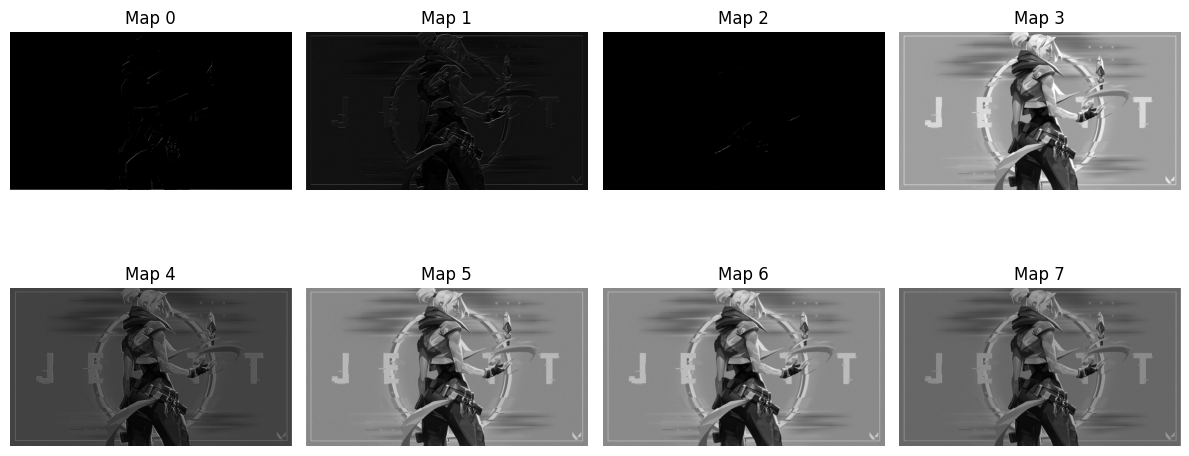

In [17]:
plot_feature_maps(
    pooled_maps,
    max_maps=8
)

In [18]:
print(
    "Before Pooling:",
    feature_maps.shape
)

print(
    "After Pooling:",
    pooled_maps.shape
)

Before Pooling: (8, 1080, 1920)
After Pooling: (8, 540, 960)


Part 6 - Pooling Preserves Important Features

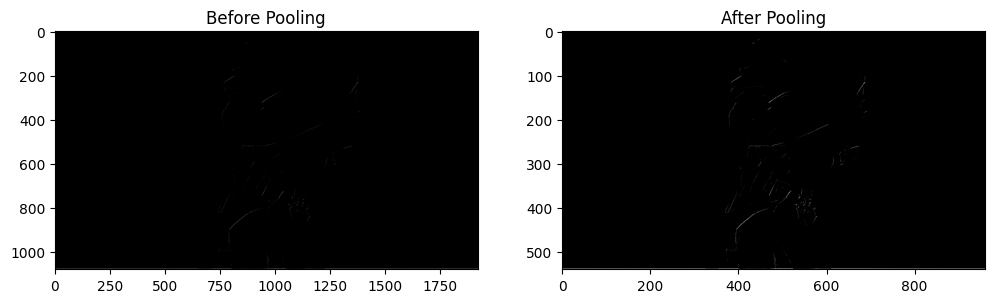

In [19]:
index = 0

fig, ax = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

ax[0].imshow(
    feature_maps[index],
    cmap="gray"
)

ax[0].set_title(
    "Before Pooling"
)

ax[1].imshow(
    pooled_maps[index],
    cmap="gray"
)

ax[1].set_title(
    "After Pooling"
)

plt.show()

Part 7 - Max Pooling backward intuition

In [20]:
window = np.array(
[
    [1,5],
    [2,3]
]
)

print(window)

[[1 5]
 [2 3]]


In [21]:
before = np.prod(
    feature_maps.shape
)

after = np.prod(
    pooled_maps.shape
)

print(
    "Values Before:",
    before
)

print(
    "Values After:",
    after
)

print(
    f"Compression: {before/after:.1f}x"
)

Values Before: 16588800
Values After: 4147200
Compression: 4.0x
